In [1]:
from google.colab import files
uploaded = files.upload()
print(uploaded)

Saving Country-data.csv to Country-data.csv
{'Country-data.csv': b'country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp\r\nAfghanistan,90.2,10,7.58,44.9,1610,9.44,56.2,5.82,553\r\nAlbania,16.6,28,6.55,48.6,9930,4.49,76.3,1.65,4090\r\nAlgeria,27.3,38.4,4.17,31.4,12900,16.1,76.5,2.89,4460\r\nAngola,119,62.3,2.85,42.9,5900,22.4,60.1,6.16,3530\r\nAntigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200\r\nArgentina,14.5,18.9,8.1,16,18700,20.9,75.8,2.37,10300\r\nArmenia,18.1,20.8,4.4,45.3,6700,7.77,73.3,1.69,3220\r\nAustralia,4.8,19.8,8.73,20.9,41400,1.16,82,1.93,51900\r\nAustria,4.3,51.3,11,47.8,43200,0.873,80.5,1.44,46900\r\nAzerbaijan,39.2,54.3,5.88,20.7,16000,13.8,69.1,1.92,5840\r\nBahamas,13.8,35,7.89,43.7,22900,-0.393,73.8,1.86,28000\r\nBahrain,8.6,69.5,4.97,50.9,41100,7.44,76,2.16,20700\r\nBangladesh,49.4,16,3.52,21.8,2440,7.14,70.4,2.33,758\r\nBarbados,14.2,39.5,7.97,48.7,15300,0.321,76.7,1.78,16000\r\nBelarus,5.5,51.4,5.61,64.5,16200,15.1,7

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
X = df.drop("country", axis=1)

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

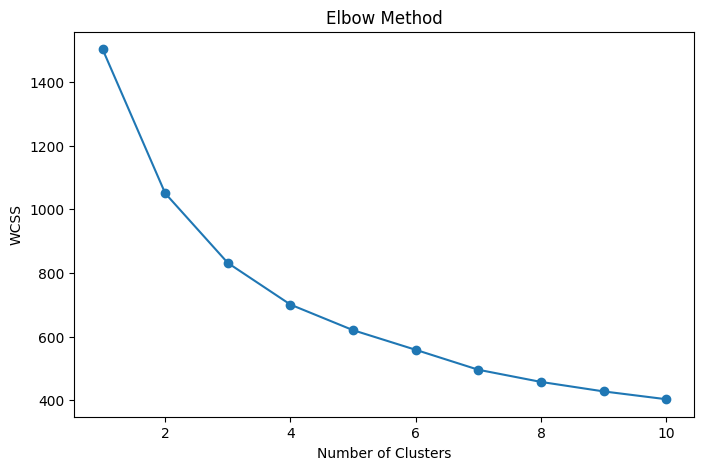

In [8]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [9]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [10]:
clusters = kmeans.fit_predict(X_scaled)

In [11]:
df["Cluster"] = clusters

In [12]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [13]:
for i in range(3):

    print("\nCluster", i)

    print(
        df[df["Cluster"]==i]["country"]
    )


Cluster 0
7                 Australia
8                   Austria
11                  Bahrain
15                  Belgium
23                   Brunei
29                   Canada
42                   Cyprus
43           Czech Republic
44                  Denmark
53                  Finland
54                   France
58                  Germany
60                   Greece
68                  Iceland
73                  Ireland
74                   Israel
75                    Italy
77                    Japan
82                   Kuwait
91               Luxembourg
98                    Malta
110             Netherlands
111             New Zealand
114                  Norway
122                Portugal
123                   Qatar
133               Singapore
134         Slovak Republic
135                Slovenia
138             South Korea
139                   Spain
144                  Sweden
145             Switzerland
157    United Arab Emirates
158          United Kingdom
159      

In [14]:
from sklearn.decomposition import PCA

In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

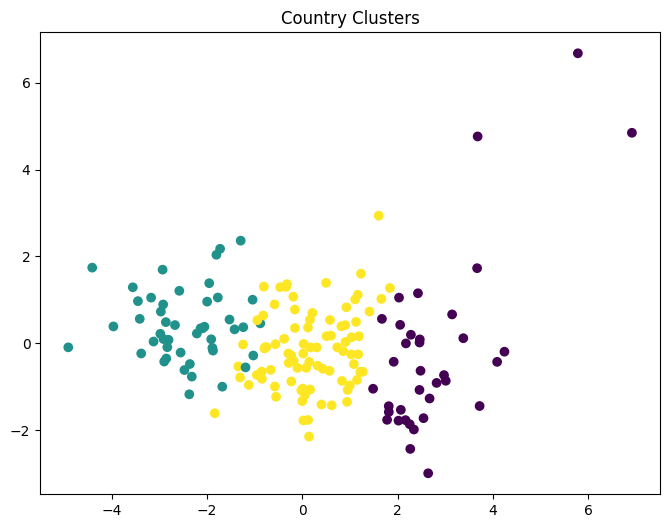

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title("Country Clusters")

plt.show()